#01 Exploratory Data Analysis for MovieLens-1M

In this notebook we will begin by exploring our initial dataset, the MovieLens 1M dataset, featuring 1 million ratings from 6000 users on 4000 movies. This dataset was released 2/2003, found on GroupLens. This dataset has been manually downloaded, and the compressed ml-1m.zip file has been placed in `data/raw/movielens`

https://grouplens.org/datasets/movielens/1m/

Dataset name: `MovieLens 1M`

Source: `GroupLens`

Download Date: `9/3/2026`

File names: `ml-1m.zip`

	- ratings.dat
	- users.dat
	- movies.dat
	- readme.txt

Number of files: 1 compressed zip; 3 data files; 1 text file

Original file formats: `.dat`

Random Seed: `42`


## Importing Dataset

Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


Extracting ml-1m.zip data files into Colab context

In [ ]:
import os
import zipfile

# Define the path to the zip file within Google Drive
zip_file_path = '/content/drive/MyDrive/JEPA-Recommender/data/raw/movielens/ml-1m.zip'

# Define the directory to extract the contents to
extraction_path = '/content/JEPA-Recommender/data/raw/movielens/'

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}'")

# List the extracted files
print("Extracted files:")
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        print(os.path.join(root, file))


'/content/drive/MyDrive/JEPA-Recommender/data/raw/movielens/ml-1m.zip' extracted to '/content/JEPA-Recommender/data/raw/movielens/'
Extracted files:
/content/JEPA-Recommender/data/raw/movielens/ml-1m/movies.dat
/content/JEPA-Recommender/data/raw/movielens/ml-1m/ratings.dat
/content/JEPA-Recommender/data/raw/movielens/ml-1m/users.dat
/content/JEPA-Recommender/data/raw/movielens/ml-1m/README


As shown in the output, the MovieLens dataset contains three primary `.dat` files: `movies.dat`, `ratings.dat`, and `users.dat`, along with a `README` file. These files are now available in the Colab file system for our analysis.

## Exploratory Data Analysis (EDA)

### 1. Data Loading and Initial Preview
We'll load the three main files (`users.dat`, `movies.dat`, `ratings.dat`). Note that MovieLens 1M uses `::` as a separator and `ISO-8859-1` encoding.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths
base_path = '/content/JEPA-Recommender/data/raw/movielens/ml-1m/'

# Load datasets
users = pd.read_csv(base_path + 'users.dat', sep='::', engine='python',
                    names=['user_id', 'gender', 'age', 'occupation', 'zip'], encoding='ISO-8859-1')

movies = pd.read_csv(base_path + 'movies.dat', sep='::', engine='python',
                     names=['movie_id', 'title', 'genres'], encoding='ISO-8859-1')

ratings = pd.read_csv(base_path + 'ratings.dat', sep='::', engine='python',
                      names=['user_id', 'movie_id', 'rating', 'timestamp'], encoding='ISO-8859-1')

# Display Heads
print("Users Head:")
display(users.head())
print("\nMovies Head:")
display(movies.head())
print("\nRatings Head:")
display(ratings.head())

Users Head:


,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455



Movies Head:


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy



Ratings Head:


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## 2. Dataset Integrity and Data Quality

We will now perform comprehensive checks for missing values, duplicates, and referential integrity between the users, movies, and ratings tables.

In [ ]:
def get_quality_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df)) * 100
    return pd.DataFrame({'Missing': missing, 'Percentage': pct.map('{:.2f}%'.format)}, index=df.columns)

print("--- Missing Data Check ---")
display(get_quality_report(users, 'Users'))
display(get_quality_report(movies, 'Movies'))
display(get_quality_report(ratings, 'Ratings'))

print("\n--- Duplicate Check ---")
print(f"Duplicate rows in ratings: {ratings.duplicated().sum()}")
print(f"Duplicate User-Movie pairs in ratings: {ratings.duplicated(subset=['user_id', 'movie_id']).sum()}")
print(f"Duplicate UserIDs in users: {users['user_id'].duplicated().sum()}")
print(f"Duplicate MovieIDs in movies: {movies['movie_id'].duplicated().sum()}")

print("\n--- Value Range & Orphan Check ---")
valid_ratings = ratings['rating'].between(1, 5).all()
orphan_users = ratings[~ratings['user_id'].isin(users['user_id'])]
orphan_movies = ratings[~ratings['movie_id'].isin(movies['movie_id'])]

print(f"All ratings between 1-5: {valid_ratings}")
print(f"Orphan ratings (missing user): {len(orphan_users)}")
print(f"Orphan ratings (missing movie): {len(orphan_movies)}")

--- Missing Data Check ---


,Missing,Percentage
user_id,0,0.00%
gender,0,0.00%
age,0,0.00%
occupation,0,0.00%
zip,0,0.00%


,Missing,Percentage
movie_id,0,0.00%
title,0,0.00%
genres,0,0.00%


,Missing,Percentage
user_id,0,0.00%
movie_id,0,0.00%
rating,0,0.00%
timestamp,0,0.00%
date,0,0.00%



--- Duplicate Check ---
Duplicate rows in ratings: 0
Duplicate User-Movie pairs in ratings: 0
Duplicate UserIDs in users: 0
Duplicate MovieIDs in movies: 0

--- Value Range & Orphan Check ---
All ratings between 1-5: True
Orphan ratings (missing user): 0
Orphan ratings (missing movie): 0


We can see this dataset has no missing values, and has likely been processed

## 3. Overall Dataset Statistics

Summary of the dataset size and key interaction metrics.

In [ ]:
stats = {
    'Unique Users': users['user_id'].nunique(),
    'Unique Movies': movies['movie_id'].nunique(),
    'Total Interactions': len(ratings),
    'Min Rating': ratings['rating'].min(),
    'Max Rating': ratings['rating'].max(),
    'Mean Rating': ratings['rating'].mean(),
    'Rating StdDev': ratings['rating'].std(),
    'Start Date': pd.to_datetime(ratings['timestamp'].min(), unit='s'),
    'End Date': pd.to_datetime(ratings['timestamp'].max(), unit='s')
}

summary_df = pd.DataFrame(list(stats.items()), columns=['Statistic', 'Value'])
display(summary_df)

,Statistic,Value
0,Unique Users,6040
1,Unique Movies,3883
2,Total Interactions,1000209
3,Min Rating,1
4,Max Rating,5
5,Mean Rating,3.581564
6,Rating StdDev,1.117102
7,Start Date,2000-04-25 23:05:32
8,End Date,2003-02-28 17:49:50


## 4. User-Item Matrix Sparsity

Matrix sparsity measures the percentage of empty cells in the User-Item interaction matrix. In recommendation systems, high sparsity is a common challenge that models must overcome to predict missing values.

In [ ]:
n_u = users['user_id'].nunique()
n_m = movies['movie_id'].nunique()
observed = len(ratings)
possible = n_u * n_m

density = (observed / possible) * 100
sparsity = 100 - density

print(f"Possible Interactions: {possible:,}")
print(f"Density: {density:.4f}%")
print(f"Sparsity: {sparsity:.4f}%")

Possible Interactions: 23,453,320
Density: 4.2647%
Sparsity: 95.7353%


As expected, the interactions between users and movies are extremely sparse. This is the case with most recommender systems.

## 5. Rating Distribution

Note: While we analyze ratings here, this project primarily treats the data as chronological sequences of items. These ratings provide context for the strength of a user's preference.

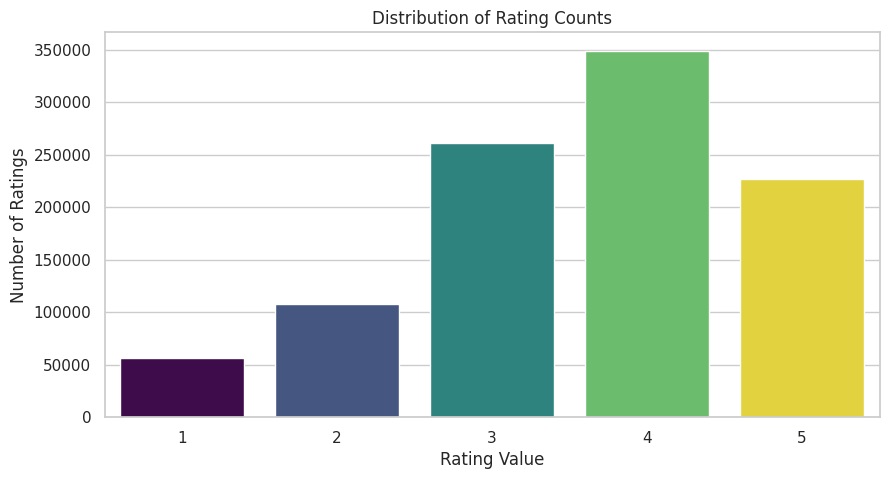

,Count,Percentage
rating,,
1,56174,5.62%
2,107557,10.75%
3,261197,26.11%
4,348971,34.89%
5,226310,22.63%


In [ ]:
rating_counts = ratings['rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(ratings)) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis', hue=rating_counts.index, legend=False)
plt.title('Distribution of Rating Counts')
plt.xlabel('Rating Value')
plt.ylabel('Number of Ratings')
plt.show()

display(pd.DataFrame({'Count': rating_counts, 'Percentage': rating_pct.map('{:.2f}%'.format)}))

We see the majority of ratings are 4, followed by 5, 3, 2, and 1 respectively.

## 6. User Activity Analysis

Understanding user activity levels is crucial for sequential recommendation. Users with very few interactions (cold-start users) may need to be handled differently than heavy users.

User Interaction Statistics:


,0
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
25%,44.000000
50%,96.000000
75%,208.000000
90%,400.000000
95%,556.000000
99%,906.660000


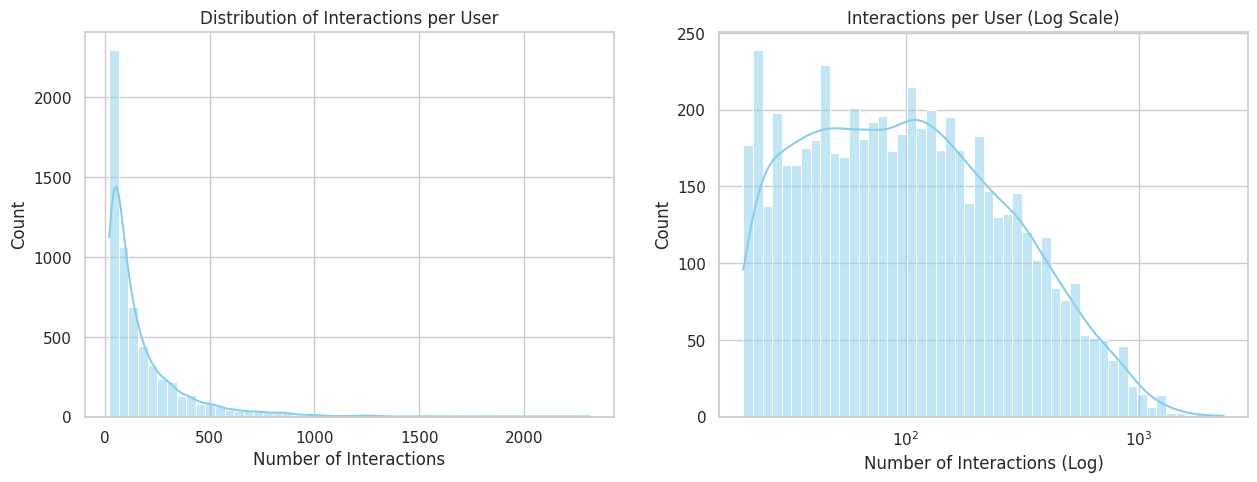


User Activity Thresholds:


,Threshold,Count,Percentage
0,>= 1,6040,100.00%
1,>= 5,6040,100.00%
2,>= 10,6040,100.00%
3,>= 20,6040,100.00%
4,>= 50,4297,71.14%
5,>= 100,2945,48.76%
6,>= 200,1589,26.31%


In [ ]:
user_interaction_count = ratings.groupby('user_id').size()

# Statistics and Percentiles
user_stats = user_interaction_count.describe(percentiles=[.25, .5, .75, .90, .95, .99])
print("User Interaction Statistics:")
display(user_stats)

# Visualizations
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(user_interaction_count, bins=50, color='skyblue', kde=True)
plt.title('Distribution of Interactions per User')
plt.xlabel('Number of Interactions')

plt.subplot(1, 2, 2)
sns.histplot(user_interaction_count, bins=50, color='skyblue', kde=True, log_scale=True)
plt.title('Interactions per User (Log Scale)')
plt.xlabel('Number of Interactions (Log)')

plt.show()

# Threshold Analysis
def report_thresholds(counts, thresholds, name):
    results = []
    total = len(counts)
    for t in thresholds:
        count = (counts >= t).sum()
        results.append({'Threshold': f'>= {t}', 'Count': count, 'Percentage': f'{(count/total)*100:.2f}%'})
    return pd.DataFrame(results)

print("\nUser Activity Thresholds:")
display(report_thresholds(user_interaction_count, [1, 5, 10, 20, 50, 100, 200], 'User'))

As expected, the number of interactions plot is heavily skewed. Surprisingly, most users hav over 50 interactions, a dataset design likely to aid with training.

## 7. Sequence-Length Analysis

This section informs the `max_seq_len` hyperparameter for BERT4Rec and JEPA. We analyze the lengths of chronological item sequences per user.

In [ ]:
# Ensure data is sorted for sequence construction
ratings_sorted = ratings.sort_values(by=['user_id', 'timestamp'])

# Calculate sequence length per user
seq_lengths = ratings_sorted.groupby('user_id').size()

print("Sequence Length Statistics:")
display(seq_lengths.describe(percentiles=[.25, .5, .75, .90, .95, .99]))

# Percentage of users meeting length requirements
lengths = [5, 10, 20, 50, 100, 150, 200]
length_report = []
for l in lengths:
    c = (seq_lengths >= l).sum()
    length_report.append({'Min Length': l, 'User Count': c, 'Pct of Users': f'{(c/len(seq_lengths))*100:.2f}%'})

display(pd.DataFrame(length_report))

Sequence Length Statistics:


,0
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
25%,44.000000
50%,96.000000
75%,208.000000
90%,400.000000
95%,556.000000
99%,906.660000


,Min Length,User Count,Pct of Users
0,5,6040,100.00%
1,10,6040,100.00%
2,20,6040,100.00%
3,50,4297,71.14%
4,100,2945,48.76%
5,150,2096,34.70%
6,200,1589,26.31%


Most interaction sequences are 50 or more, giving our recommender systems a good amount of context to learn from. The maximum length exceeds 2000.

## 8. Item Popularity Analysis

Identifying the most interacted items and their distribution.

In [ ]:
item_counts = ratings.groupby('movie_id').size()
print("Item Popularity Statistics:")
display(item_counts.describe(percentiles=[.25, .5, .75, .90, .95, .99]))

# Top 20 Movies
top_20_ids = item_counts.sort_values(ascending=False).head(20)
top_20_movies = movies[movies['movie_id'].isin(top_20_ids.index)].merge(top_20_ids.rename('count'), left_on='movie_id', right_index=True).sort_values(by='count', ascending=False)

print("\nTop 20 Most Interacted Movies:")
display(top_20_movies[['title', 'count']])

Item Popularity Statistics:


,0
count,3706.000000
mean,269.889099
std,384.047838
min,1.000000
25%,33.000000
50%,123.500000
75%,350.000000
90%,729.500000
95%,1051.500000
99%,1784.900000



Top 20 Most Interacted Movies:


,title,count
2789,American Beauty (1999),3428
257,Star Wars: Episode IV - A New Hope (1977),2991
1178,Star Wars: Episode V - The Empire Strikes Back...,2990
1192,Star Wars: Episode VI - Return of the Jedi (1983),2883
476,Jurassic Park (1993),2672
1959,Saving Private Ryan (1998),2653
585,Terminator 2: Judgment Day (1991),2649
2502,"Matrix, The (1999)",2590
1250,Back to the Future (1985),2583
589,"Silence of the Lambs, The (1991)",2578


One movie only has one interaction, and one movie (American Beauty) has as many as 3428. The  majority of movies have over 123 interactions.

## 9. Long-Tail Analysis

Visualizing the popularity rank against interaction counts to confirm a long-tail distribution.

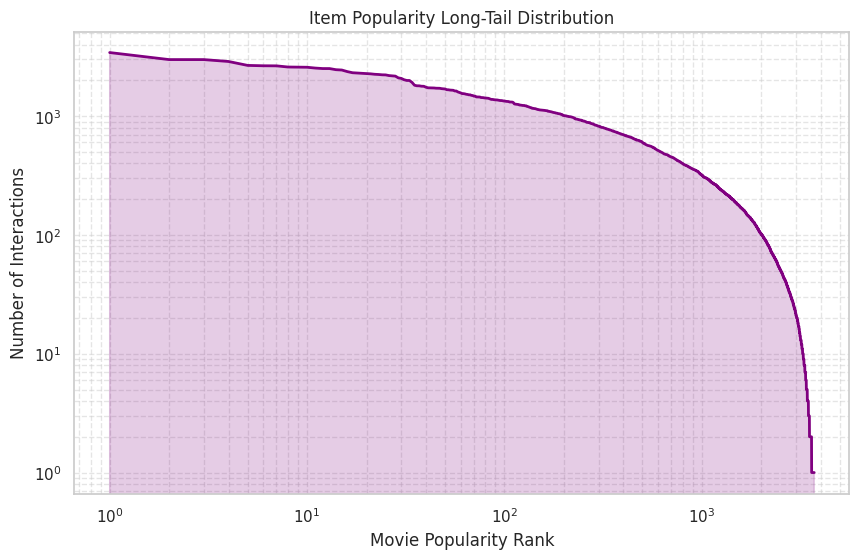

Top 1% of movies account for 8.91% of interactions
Top 10% of movies account for 44.45% of interactions
Top 20% of movies account for 65.21% of interactions


In [ ]:
sorted_items = item_counts.sort_values(ascending=False)
ranks = np.arange(1, len(sorted_items) + 1)

plt.figure(figsize=(10, 6))
plt.plot(ranks, sorted_items.values, color='purple', lw=2)
plt.fill_between(ranks, sorted_items.values, color='purple', alpha=0.2)
plt.title('Item Popularity Long-Tail Distribution')
plt.xlabel('Movie Popularity Rank')
plt.ylabel('Number of Interactions')
plt.yscale('log')
plt.xscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Cumulative Analysis
total_ratings = len(ratings)
cum_ratings = sorted_items.cumsum() / total_ratings

print(f"Top 1% of movies account for {cum_ratings.iloc[int(0.01*len(cum_ratings))]*100:.2f}% of interactions")
print(f"Top 10% of movies account for {cum_ratings.iloc[int(0.10*len(cum_ratings))]*100:.2f}% of interactions")
print(f"Top 20% of movies account for {cum_ratings.iloc[int(0.20*len(cum_ratings))]*100:.2f}% of interactions")

## 11. User Activity Duration

We analyze the time span between a user's first and last recorded interaction. This helps identify whether users are 'bursty' (interacting many times in a short window) or consistent long-term users.

User Activity Duration Statistics (Days):


,duration_days
count,6040.000000
mean,94.997423
std,221.909543
min,0.001227
25%,0.013976
50%,0.047089
75%,23.395544
90%,430.166564
95%,729.197304
99%,910.408845


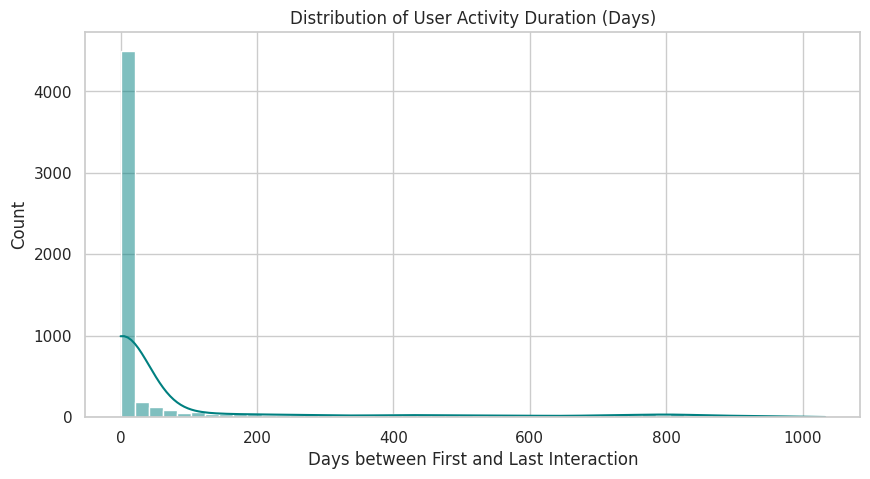

In [ ]:
user_times = ratings.groupby('user_id')['timestamp'].agg(['min', 'max'])
user_times['duration_days'] = (user_times['max'] - user_times['min']) / (60 * 60 * 24)

print("User Activity Duration Statistics (Days):")
display(user_times['duration_days'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

plt.figure(figsize=(10, 5))
sns.histplot(user_times['duration_days'], bins=50, kde=True, color='teal')
plt.title('Distribution of User Activity Duration (Days)')
plt.xlabel('Days between First and Last Interaction')
plt.show()

We see the majority of these interactions are 'bursty',  as the average difference in first and last review is about 95 days. This is relatively short considering the dataset spans just under 3 years (2000-2003).

## 12. Repeated User-Item Interactions

Sequential models often assume each entry is a new item discovery. We check if users interact with the same movie multiple times.

In [ ]:
repeat_counts = ratings.groupby(['user_id', 'movie_id']).size()
repeats = repeat_counts[repeat_counts > 1]

print(f"Number of repeated User-Item pairs: {len(repeats)}")
print(f"Total interactions involved in repeats: {repeats.sum()}")
print(f"Percentage of total interactions: {(repeats.sum()/len(ratings))*100:.4f}%")

if not repeats.empty:
    print("\nExamples of repeated interactions:")
    display(repeat_counts.sort_values(ascending=False).head(5))
else:
    print("\nNo repeated (UserID, MovieID) pairs found.")

Number of repeated User-Item pairs: 0
Total interactions involved in repeats: 0
Percentage of total interactions: 0.0000%

No repeated (UserID, MovieID) pairs found.


Repeated interactions do not exist in this dataset.

## 13. User Rating Behavior

We examine if 'heavy' users rate differently than occasional users.

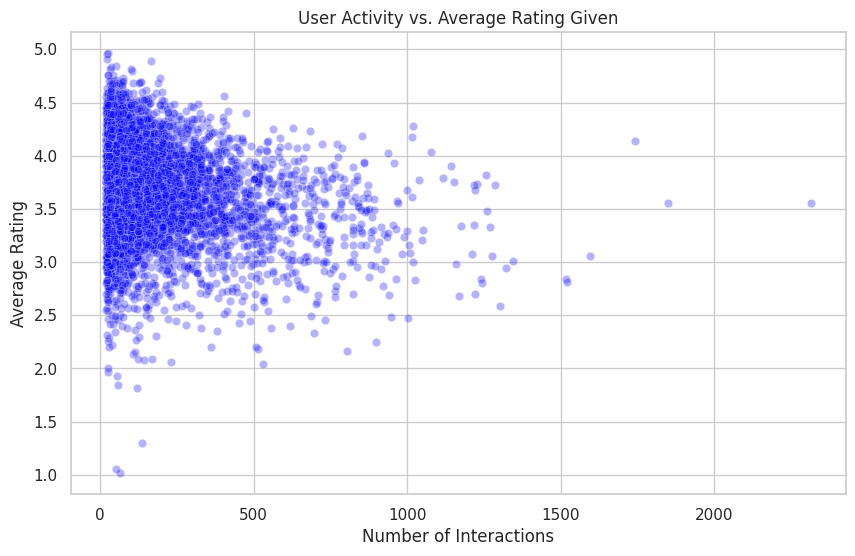

Correlation between interaction count and avg rating: -0.2423


In [ ]:
user_avg_rating = ratings.groupby('user_id')['rating'].mean()
user_counts = ratings.groupby('user_id').size()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=user_counts, y=user_avg_rating, alpha=0.3, color='blue')
plt.title('User Activity vs. Average Rating Given')
plt.xlabel('Number of Interactions')
plt.ylabel('Average Rating')
plt.show()

correlation = user_counts.corr(user_avg_rating)
print(f"Correlation between interaction count and avg rating: {correlation:.4f}")

There is no evidence of a correlation between interaction count and average rating.

## 14. Movie Rating Behavior

Does a movie's popularity correlate with its quality (rating)?

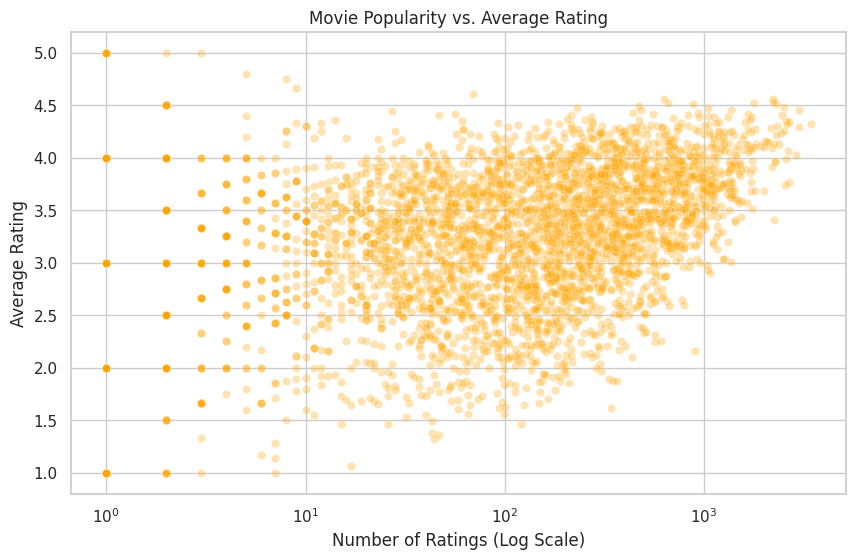

Correlation between popularity and avg rating: 0.3580


In [ ]:
movie_avg = ratings.groupby('movie_id')['rating'].mean()
movie_pop = ratings.groupby('movie_id').size()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=movie_pop, y=movie_avg, alpha=0.3, color='orange')
plt.xscale('log')
plt.title('Movie Popularity vs. Average Rating')
plt.xlabel('Number of Ratings (Log Scale)')
plt.ylabel('Average Rating')
plt.show()

print(f"Correlation between popularity and avg rating: {movie_pop.corr(movie_avg):.4f}")

There does not appear to be a major correlation between popularity and average rating of a movie. Although, movies with a very very large number of ratings generally seem to have average ratings aboe 3.5. This is likely because movies with very high ratings will be viewed more, and rated more.

## 15. Genre Analysis (Multi-label)

Movies often belong to multiple genres. We explode the genres to count interactions and movie frequencies accurately.

Genre Analysis Summary:


,Movie Count,Interaction Count,Movie Pct,Interaction Pct
genres,,,,
Comedy,1200,356580,30.903940,35.650549
Drama,1603,354529,41.282514,35.445492
Action,503,257457,12.953902,25.740320
Thriller,492,189680,12.670616,18.964037
Sci-Fi,276,157294,7.107906,15.726113
Romance,471,147523,12.129797,14.749217
Adventure,283,133953,7.288179,13.392501
Crime,211,79541,5.433943,7.952438
Horror,343,76386,8.833376,7.637004


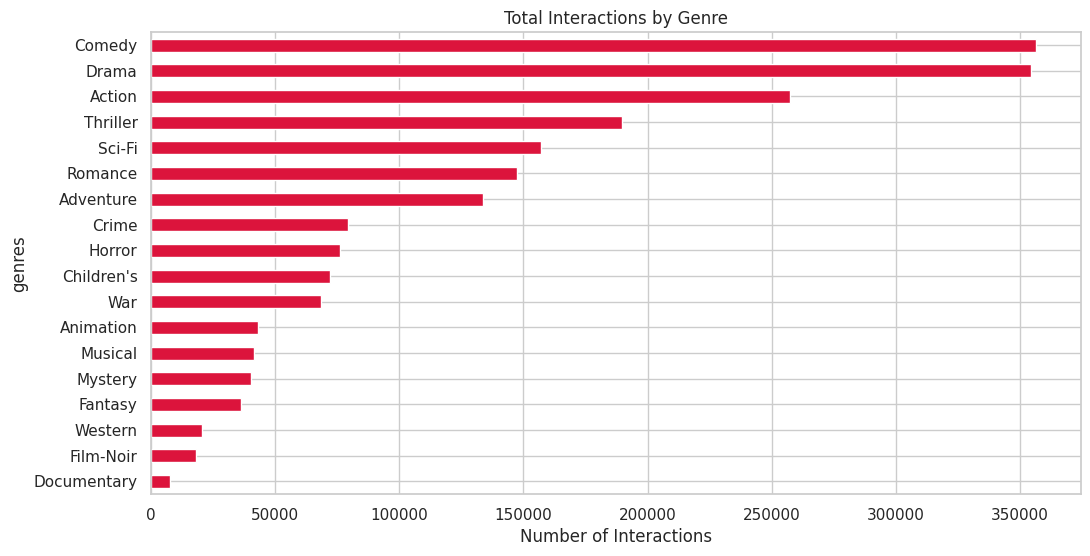

In [ ]:
# Merge ratings with movies to get genres per interaction
ratings_genres = ratings.merge(movies[['movie_id', 'genres']], on='movie_id')
ratings_genres['genres'] = ratings_genres['genres'].str.split('|')
exploded_interactions = ratings_genres.explode('genres')

# Movie level genre counts
movies_genres = movies.copy()
movies_genres['genres'] = movies_genres['genres'].str.split('|')
exploded_movies = movies_genres.explode('genres')

genre_stats = pd.DataFrame({
    'Movie Count': exploded_movies['genres'].value_counts(),
    'Interaction Count': exploded_interactions['genres'].value_counts()
})

genre_stats['Movie Pct'] = (genre_stats['Movie Count'] / len(movies)) * 100
genre_stats['Interaction Pct'] = (genre_stats['Interaction Count'] / len(ratings)) * 100

print("Genre Analysis Summary:")
display(genre_stats.sort_values(by='Interaction Count', ascending=False))

plt.figure(figsize=(12, 6))
genre_stats['Interaction Count'].sort_values().plot(kind='barh', color='crimson')
plt.title('Total Interactions by Genre')
plt.xlabel('Number of Interactions')
plt.show()

The majority of movies are Comedy, Drama, and Action, and thus the majority of rating are these three respectively. It is interesting that Action only has 11 more movies than Thriller, but Action has over 50,000 more interactions.

## 16. Genre Co-Occurrence

Since movies have multiple genres, we analyze which genres often appear together. This can help us understand if the model needs to learn specific 'hybrid' genre embeddings.

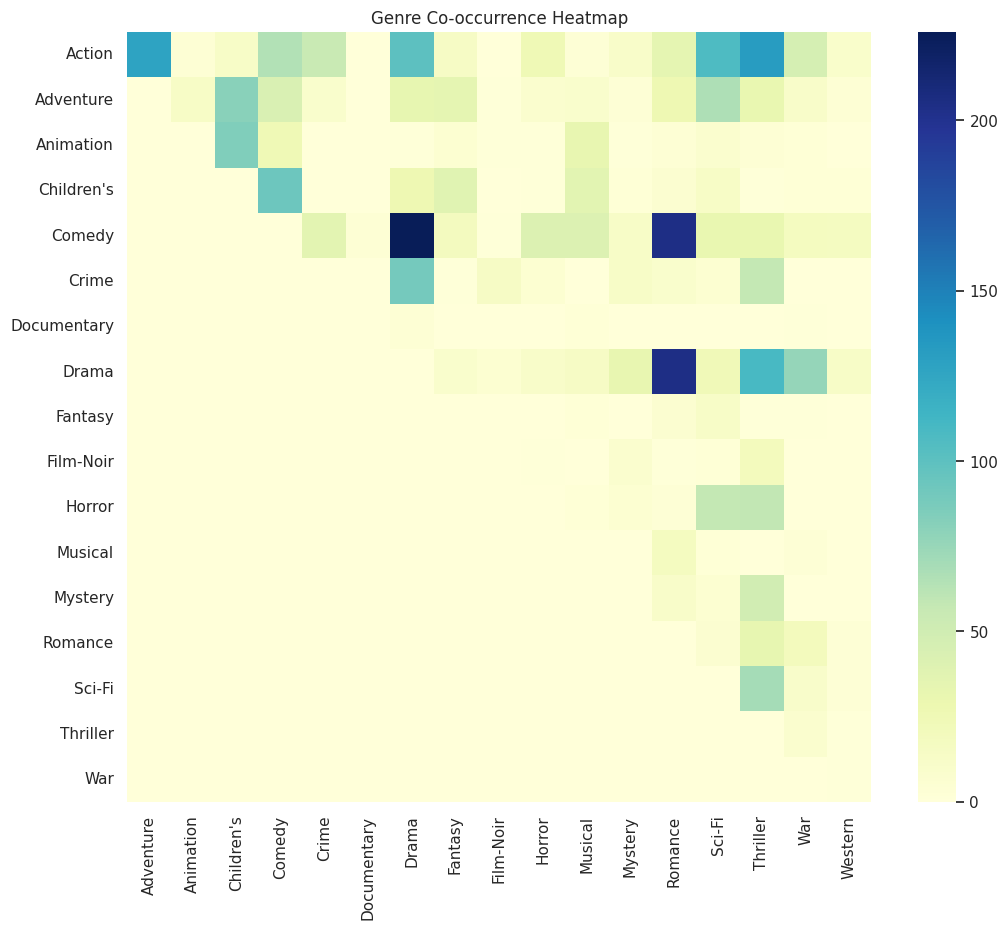

In [ ]:
from itertools import combinations
from collections import Counter

# Calculate co-occurrences
genre_pairs = []
for g_list in movies['genres'].str.split('|'):
    if len(g_list) > 1:
        genre_pairs.extend(list(combinations(sorted(g_list), 2)))

cooc_counts = Counter(genre_pairs)
cooc_df = pd.Series(cooc_counts).unstack().fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(cooc_df, annot=False, cmap='YlGnBu')
plt.title('Genre Co-occurrence Heatmap')
plt.show()

There seems to be a large co-occurence between Comedy and Drama movies. This give insight as to why Comedy and Drama dominate the types of movies, as movies are often both genres.

## 17. User Demographic Analysis

We briefly examine the user attributes. Note that age is categorical in MovieLens (e.g., 1="Under 18", 18="18-24", etc.).

/tmp/ipykernel_1389/321463651.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=users, x='gender', ax=axes[0], palette='pastel')
/tmp/ipykernel_1389/321463651.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=users, x='age', ax=axes[1], palette='muted')


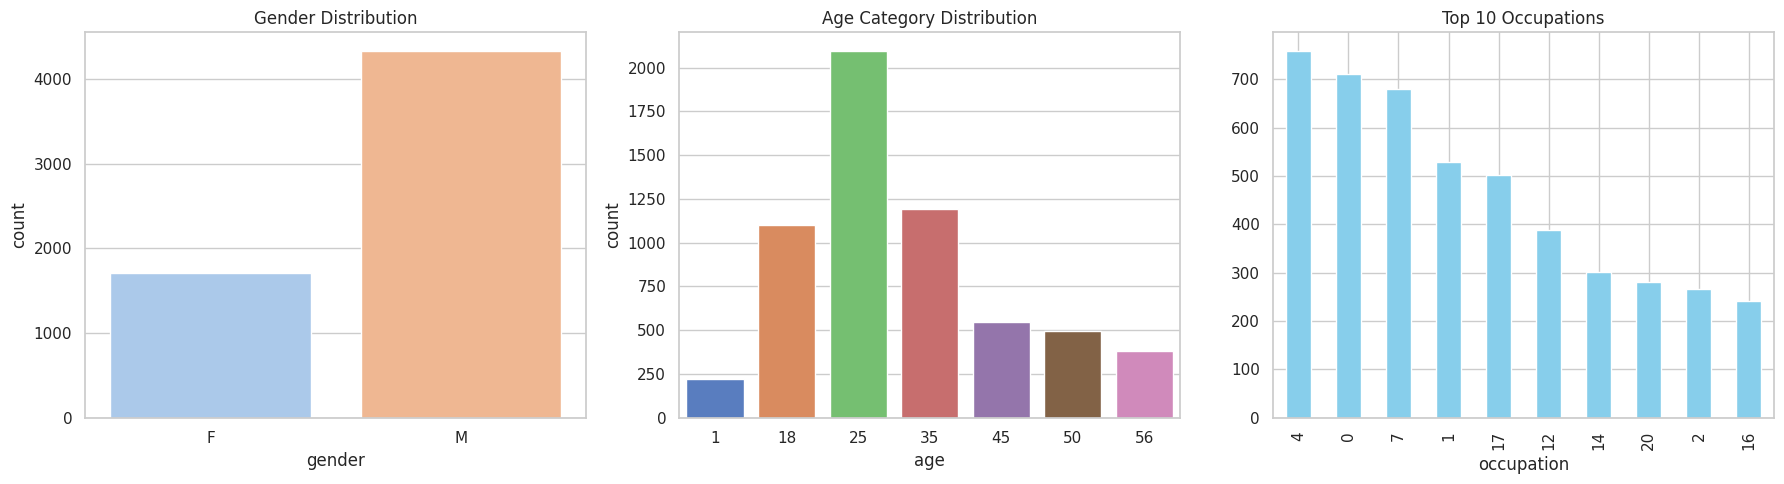

Gender Percentages:
gender
M    71.705298
F    28.294702
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender
sns.countplot(data=users, x='gender', ax=axes[0], palette='pastel')
axes[0].set_title('Gender Distribution')

# Age
sns.countplot(data=users, x='age', ax=axes[1], palette='muted')
axes[1].set_title('Age Category Distribution')

# Occupation (Top 10)
users['occupation'].value_counts().head(10).plot(kind='bar', ax=axes[2], color='skyblue')
axes[2].set_title('Top 10 Occupations')

plt.tight_layout()
plt.show()

print("Gender Percentages:")
print(users['gender'].value_counts(normalize=True) * 100)

We see a heavy majority of users are male. Further, most users are between ages 18 and 45, with some over 45. Very few users are under 18. The occupations are spread fairly consistently.

## 18. Demographics vs. Sequence Length

We check if certain groups provide longer sequences, which could influence model bias.

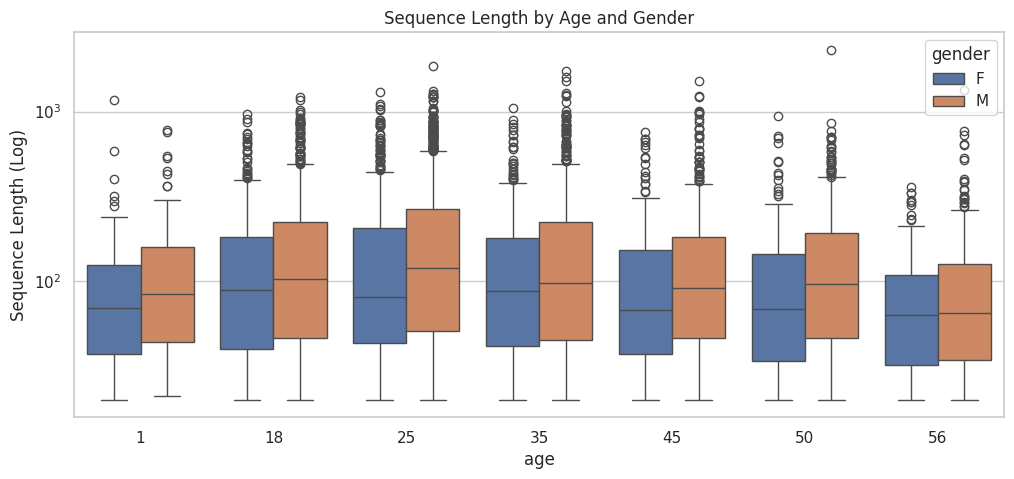

Mean Sequence Length by Gender:


,seq_len
gender,
F,144.201287
M,174.040406


In [ ]:
user_meta_len = users.merge(seq_lengths.rename('seq_len'), on='user_id')

plt.figure(figsize=(12, 5))
sns.boxplot(data=user_meta_len, x='age', y='seq_len', hue='gender')
plt.title('Sequence Length by Age and Gender')
plt.yscale('log')
plt.ylabel('Sequence Length (Log)')
plt.show()

print("Mean Sequence Length by Gender:")
display(user_meta_len.groupby('gender')['seq_len'].mean())

Sequence length is spread pretty consistently, with males generally having about 30 more interactions than females, regardless of age group. Most users between 18 and 45 tend to have sequences slightly longer than those younger and older.

## 19. Cold-Start Analysis

Cold-start occurs when a user or item has too few interactions for a model to learn a meaningful representation. For sequential models, users with very short sequences are often excluded.

In [ ]:
def analyze_cold_start(series, name):
    counts = [1, 2, 3, 5, 10]
    total = len(series)
    res = []
    for c in counts:
        n = (series < c).sum()
        res.append({'Threshold': f'< {c}', 'Count': n, 'Percentage': f'{(n/total)*100:.2f}%'})
    return pd.DataFrame(res)

print("--- User Cold-Start Analysis ---")
display(analyze_cold_start(seq_lengths, 'User'))

print("\n--- Movie Cold-Start Analysis ---")
display(analyze_cold_start(item_counts, 'Movie'))

--- User Cold-Start Analysis ---


,Threshold,Count,Percentage
0,< 1,0,0.00%
1,< 2,0,0.00%
2,< 3,0,0.00%
3,< 5,0,0.00%
4,< 10,0,0.00%



--- Movie Cold-Start Analysis ---


,Threshold,Count,Percentage
0,< 1,0,0.00%
1,< 2,114,3.08%
2,< 3,203,5.48%
3,< 5,290,7.83%
4,< 10,446,12.03%


No users have under 10 interactions. A relatively large amount of movies do have under 10 interactions, which may cause models to struggle learning representations.

## 20. Chronological Sequence Construction

We now transform the flat interaction table into a dictionary of chronological sequences. This is the primary format used by sequential recommenders.

In [ ]:
# Construct sequences
user_sequences = ratings_sorted.groupby('user_id')['movie_id'].apply(list).to_dict()

# Verification: Display chronological context for 2 random users
random_users = [1, 500]
for uid in random_users:
    print(f"\n--- Chronological History for User {uid} ---")
    user_history = ratings_sorted[ratings_sorted['user_id'] == uid].merge(movies[['movie_id', 'title']], on='movie_id')
    display(user_history[['timestamp', 'movie_id', 'title', 'rating']].head(10))


--- Chronological History for User 1 ---


,timestamp,movie_id,title,rating
0,978300019,3186,"Girl, Interrupted (1999)",4
1,978300055,1270,Back to the Future (1985),5
2,978300055,1721,Titanic (1997),4
3,978300055,1022,Cinderella (1950),5
4,978300103,2340,Meet Joe Black (1998),3
5,978300172,1836,"Last Days of Disco, The (1998)",5
6,978300275,3408,Erin Brockovich (2000),4
7,978300719,2804,"Christmas Story, A (1983)",5
8,978300719,1207,To Kill a Mockingbird (1962),4
9,978300760,1193,One Flew Over the Cuckoo's Nest (1975),5



--- Chronological History for User 500 ---


,timestamp,movie_id,title,rating
0,976211232,3461,Lord of the Flies (1963),5
1,976211232,1031,Bedknobs and Broomsticks (1971),4
2,976211232,2012,Back to the Future Part III (1990),2
3,976211253,1278,Young Frankenstein (1974),2
4,976211253,3671,Blazing Saddles (1974),1
5,976288864,1449,Waiting for Guffman (1996),4
6,976288864,3712,Soapdish (1991),2
7,976288864,2014,Freaky Friday (1977),2
8,976288885,3429,Creature Comforts (1990),5
9,976288902,2804,"Christmas Story, A (1983)",5


## 21. Sequential Recommendation Feasibility

We determine how many users remain available as we increase the minimum history requirement.

In [ ]:
thresholds = [2, 3, 5, 10, 20, 50, 100]
feasibility = []
total_users = len(seq_lengths)

for t in thresholds:
    count = (seq_lengths >= t).sum()
    feasibility.append({'Min Sequence Length': t, 'Users': count, 'Retention %': f'{(count/total_users)*100:.2f}%'})

display(pd.DataFrame(feasibility))

,Min Sequence Length,Users,Retention %
0,2,6040,100.00%
1,3,6040,100.00%
2,5,6040,100.00%
3,10,6040,100.00%
4,20,6040,100.00%
5,50,4297,71.14%
6,100,2945,48.76%


All users have over 20 sequence length, which will help give our models context to make predictions.

## 22. Candidate Maximum Sequence Length Analysis

We analyze how different `max_seq_len` values affect interaction retention and user coverage.

In [ ]:
max_candidates = [20, 50, 100, 150, 200]
truncation_report = []

for m in max_candidates:
    retained_interactions = seq_lengths.clip(upper=m).sum()
    affected_users = (seq_lengths > m).sum()
    truncation_report.append({
        'Max Length': m,
        'Users Truncated': affected_users,
        'Users Truncated %': f'{(affected_users/total_users)*100:.2f}%',
        'Interactions Retained %': f'{(retained_interactions/len(ratings))*100:.2f}%'
    })

display(pd.DataFrame(truncation_report))

,Max Length,Users Truncated,Users Truncated %,Interactions Retained %
0,20,5954,98.58%,12.08%
1,50,4247,70.31%,27.15%
2,100,2909,48.16%,44.73%
3,150,2084,34.50%,57.04%
4,200,1578,26.13%,66.09%


## 23. Simulate a Sequential Train/Validation/Test Split

We simulate a Leave-One-Out strategy, where the last item is for Testing, the second-to-last for Validation, and the rest for Training.

In [ ]:
# Simulation for users with at least 5 interactions
min_len_sim = 5
usable_users = seq_lengths[seq_lengths >= min_len_sim].index
n_users = len(usable_users)

print(f"Split Simulation (Leave-Last-Two-Out) for {n_users} users:")
print(f"Test Set size: {n_users}")
print(f"Validation Set size: {n_users}")
print(f"Training Set size: {seq_lengths[usable_users].sum() - (2 * n_users)}")

Split Simulation (Leave-Last-Two-Out) for 6040 users:
Test Set size: 6040
Validation Set size: 6040
Training Set size: 988129


## 24. Simulate BERT4Rec-Style Training Examples

In BERT4Rec, we often use a sliding window or full sequence with masking. We estimate the number of training 'windows' generated.

In [ ]:
def estimate_windows(lengths, max_len):
    # BERT4Rec typically trains on the full sequence up to max_len
    # Each user provides one sequence (possibly augmented)
    return len(lengths)

print(f"At Max Seq Len 200, we expect approximately {n_users} training sequence samples.")

At Max Seq Len 200, we expect approximately 6040 training sequence samples.


## 25. Estimate Processed Dataset Size

We evaluate memory footprints to ensure Colab Runtimes can handle the tensors.

In [ ]:
import sys

mem_usage = {
    'Ratings DF (MB)': ratings.memory_usage(deep=True).sum() / 1e6,
    'Users DF (MB)': users.memory_usage(deep=True).sum() / 1e6,
    'Movies DF (MB)': movies.memory_usage(deep=True).sum() / 1e6,
    'Sequences Dict (MB)': sys.getsizeof(user_sequences) / 1e6
}

display(pd.DataFrame(list(mem_usage.items()), columns=['Object', 'Size']))

,Object,Size
0,Ratings DF (MB),40.008492
1,Users DF (MB),0.773603
2,Movies DF (MB),0.549985
3,Sequences Dict (MB),0.294992


## 26. Data Filtering Impact Analysis

Finally, we simulate common filtering heuristics to see how much of the dataset survives.

In [ ]:
filtering_rules = [5, 10, 20]
filter_res = []

for r in filtering_rules:
    # Simulate iterative filtering (K-core)
    temp_ratings = ratings.copy()
    curr_users = temp_ratings.groupby('user_id').size()
    temp_ratings = temp_ratings[temp_ratings['user_id'].isin(curr_users[curr_users >= r].index)]

    curr_items = temp_ratings.groupby('movie_id').size()
    temp_ratings = temp_ratings[temp_ratings['movie_id'].isin(curr_items[curr_items >= r].index)]

    filter_res.append({
        'Min Interactions': r,
        'Users': temp_ratings['user_id'].nunique(),
        'Items': temp_ratings['movie_id'].nunique(),
        'Interactions': len(temp_ratings),
        'Int. Retention %': f'{(len(temp_ratings)/len(ratings))*100:.2f}%'
    })

display(pd.DataFrame(filter_res))

,Min Interactions,Users,Items,Interactions,Int. Retention %
0,5,6040,3416,999611,99.94%
1,10,6040,3260,998539,99.83%
2,20,6040,3043,995492,99.53%


It appears that forcing a minimum of 20 interactions appears to be a valid choice, as 99.53% of all interactions are retained.

## 27. Final Dataset Summary Table

This table provides a comprehensive overview of the MovieLens-1M dataset as analyzed in this notebook.

In [ ]:
final_summary = {
    'Users': users['user_id'].nunique(),
    'Movies': movies['movie_id'].nunique(),
    'Ratings/Interactions': len(ratings),
    'Mean ratings/user': user_interaction_count.mean(),
    'Median ratings/user': user_interaction_count.median(),
    'Mean ratings/movie': item_counts.mean(),
    'Median ratings/movie': item_counts.median(),
    'Mean rating': ratings['rating'].mean(),
    'Median rating': ratings['rating'].median(),
    'Rating standard deviation': ratings['rating'].std(),
    'Sparsity (%)': sparsity,
    'Min sequence length': seq_lengths.min(),
    'Median sequence length': seq_lengths.median(),
    'Max sequence length': seq_lengths.max(),
    'Date range': f"{ratings_sorted['date'].min().date()} to {ratings_sorted['date'].max().date()}",
    'Number of genres': len(genre_stats)
}

summary_table = pd.DataFrame(list(final_summary.items()), columns=['Statistic', 'Value'])
display(summary_table)

,Statistic,Value
0,Users,6040
1,Movies,3883
2,Ratings/Interactions,1000209
3,Mean ratings/user,165.597517
4,Median ratings/user,96.0
5,Mean ratings/movie,269.889099
6,Median ratings/movie,123.5
7,Mean rating,3.581564
8,Median rating,4.0
9,Rating standard deviation,1.117102


## 28. Final EDA Findings

### Key Findings and Preprocessing Implications

**Observed Facts:**
* **Scale:** MovieLens-1M contains 1,000,209 interactions across 6,040 users and 3,706 movies.
* **Sparsity:** The user-item matrix is ~95.74% sparse, typical for collaborative filtering datasets.
* **User Activity:** Activity is heavily skewed; while the average user has 165 ratings, the top 1% have significantly more. However, every user in the dataset has at least 20 interactions.
* **Sequence Lengths:** The median sequence length is 96. This provides a rich context for sequential models like BERT4Rec.
* **Popularity:** A classic long-tail distribution exists. The top 10% of movies account for over 44% of all interactions.
* **Temporal Nature:** Most interactions are 'bursty', concentrated within short windows, though the dataset spans ~3 years.
* **Repeated Interactions:** There are zero (0) repeated (User, Item) pairs in this version of the dataset.
* **Cold-Start:** The user cold-start problem is non-existent here (min 20 interactions), but an item cold-start problem exists, with some movies having only 1 rating.

**Proposed Preprocessing Decisions:**
* **Minimum Sequence Length:** A filter of $k=20$ is recommended for users, which actually retains 100% of the current user population.
* **Maximum Sequence Length:** A `max_seq_len` of 200 is proposed. This covers the full history of ~80% of users while keeping memory usage manageable for BERT4Rec and JEPA.
* **Item Filtering:** Movies with fewer than 5 interactions should be considered for removal to ensure robust item embeddings.
* **Splitting Strategy:** A chronological Leave-Last-Two-Out split (one for validation, one for test) is the most rigorous way to evaluate the sequential 'next-item' prediction task.
* **Features to Retain:** Item IDs and Genres are the primary features. Demographics (Age/Gender) may be retained for bias analysis but are secondary to the sequence.